# EDA — MovieLens 1M

**Goal**: Understand the data well enough to finalize the train/test split strategy, confirm whether feature engineering is needed, and anticipate problems.

**Files**
- `ratings.dat`: UserID, MovieID, Rating, Timestamp (1M rows)
- `users.dat`  : UserID, Gender, Age, Occupation, Zip-code (6,040 rows)
- `movies.dat` : MovieID, Title, Genres (3,883 rows)

**Key questions to answer in this notebook/eda**
1. Basic statistics: how many users, items, ratings? What is the matrix density?
2. User activity: distribution of interactions per user — where is the long tail? How does 20% subsampling hurt the sparsest users?
3. Item popularity: power-law? How many items are never in the top-100 candidates?
4. Rating distribution: do we binarize (implicit) or keep as-is?
5. Temporal structure: are timestamps usable for leave-one-out split?
6. User demographics and movie genres: do we need them for the models?
7. ID gaps and data quality issues.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
DATA = Path('../data/raw/ml-1m')
FIG  = Path('../figures')
FIG.mkdir(exist_ok=True)

## 1. Load raw data

In [4]:
ratings = pd.read_csv(
    DATA / 'ratings.dat', sep='::', engine='python', header=None,
    names=['user_id', 'movie_id', 'rating', 'timestamp'],
    dtype={'user_id': np.int32, 'movie_id': np.int32, 'rating': np.float32, 'timestamp': np.int64}
)

users = pd.read_csv(
    DATA / 'users.dat', sep='::', engine='python', header=None,
    names=['user_id', 'gender', 'age', 'occupation', 'zip'],
    dtype={'user_id': np.int32}
)

movies = pd.read_csv(
    DATA / 'movies.dat', sep='::', engine='python', header=None,
    names=['movie_id', 'title', 'genres'],
    encoding='latin-1',
    dtype={'movie_id': np.int32}
)

print(f'Ratings : {len(ratings):,}')
print(f'Users   : {len(users):,}')
print(f'Movies  : {len(movies):,}')
ratings.head()

Ratings : 1,000,209
Users   : 6,040
Movies  : 3,883


,user_id,movie_id,rating,timestamp
0,1,1193,5.0,978300760
1,1,661,3.0,978302109
2,1,914,3.0,978301968
3,1,3408,4.0,978300275
4,1,2355,5.0,978824291


In [5]:
users.head()

,user_id,gender,age,occupation,zip
0,1,F,1,10,48067
1,2,M,56,16,70072
2,3,M,25,15,55117
3,4,M,45,7,02460
4,5,M,25,20,55455


In [6]:
movies.head()

,movie_id,title,genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy


## 2. Basic statistics

In [7]:
n_users  = ratings['user_id'].nunique()
n_items  = ratings['movie_id'].nunique()
n_ratings = len(ratings)
density  = n_ratings / (n_users * n_items)

print(f'Unique users  : {n_users:,}')
print(f'Unique movies : {n_items:,}')
print(f'Ratings       : {n_ratings:,}')
print(f'Matrix density: {density:.4%}  ({density:.5f})')
print(f'Sparsity      : {1-density:.4%}')
print()
print('Rating value distribution:')
print(ratings['rating'].value_counts().sort_index())

Unique users  : 6,040
Unique movies : 3,706
Ratings       : 1,000,209
Matrix density: 4.4684%  (0.04468)
Sparsity      : 95.5316%

Rating value distribution:
rating
1.0     56174
2.0    107557
3.0    261197
4.0    348971
5.0    226310
Name: count, dtype: int64


In [8]:
# Check for movie IDs in ratings that are NOT in movies.dat
missing_movies = set(ratings['movie_id'].unique()) - set(movies['movie_id'].unique())
print(f'Movie IDs in ratings but not in movies.dat: {len(missing_movies)}')
print(f'Movie ID range in ratings.dat: {ratings["movie_id"].min()} – {ratings["movie_id"].max()}')
print(f'Movie ID range in movies.dat : {movies["movie_id"].min()} – {movies["movie_id"].max()}')

# Are all users in ratings also in users.dat?
missing_users = set(ratings['user_id'].unique()) - set(users['user_id'].unique())
print(f'User IDs in ratings but not in users.dat: {len(missing_users)}')

Movie IDs in ratings but not in movies.dat: 0
Movie ID range in ratings.dat: 1 – 3952
Movie ID range in movies.dat : 1 – 3952
User IDs in ratings but not in users.dat: 0


## 3. Rating distribution

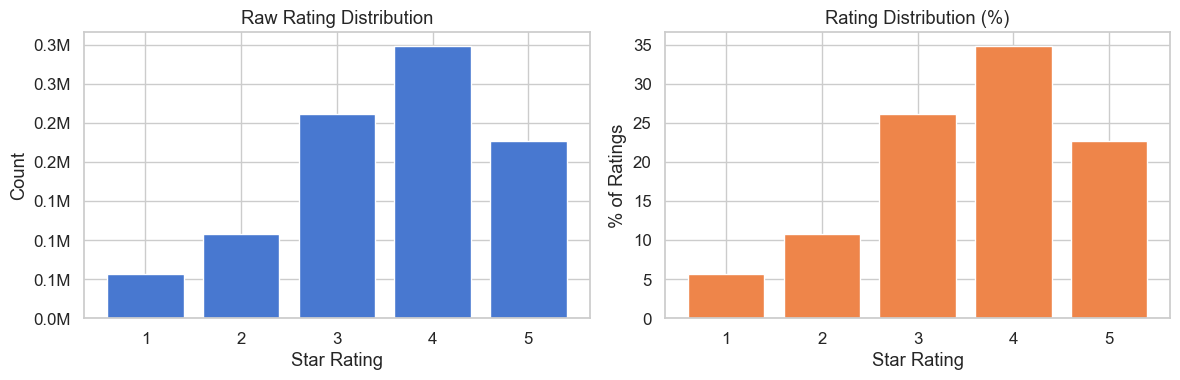

Mean rating: 3.582
Median     : 4.0

NOTE: For implicit feedback models (MF, NCF, ranker) we treat any observed
rating as a positive interaction and ignore the star value.
Binarization: rating >= 1 → 1 (positive), unobserved → 0 (negative).


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Raw rating counts
vc = ratings['rating'].value_counts().sort_index()
axes[0].bar(vc.index, vc.values, color=sns.color_palette()[0], edgecolor='white')
axes[0].set_xlabel('Star Rating')
axes[0].set_ylabel('Count')
axes[0].set_title('Raw Rating Distribution')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

# Cumulative proportion
axes[1].bar(vc.index, vc.values / vc.sum() * 100, color=sns.color_palette()[1], edgecolor='white')
axes[1].set_xlabel('Star Rating')
axes[1].set_ylabel('% of Ratings')
axes[1].set_title('Rating Distribution (%)')

plt.tight_layout()
plt.savefig(FIG / 'eda_rating_distribution.png', dpi=150)
plt.show()

print(f'Mean rating: {ratings["rating"].mean():.3f}')
print(f'Median     : {ratings["rating"].median():.1f}')
print()
print('NOTE: For implicit feedback models (MF, NCF, ranker) we treat any observed')
print('rating as a positive interaction and ignore the star value.')
print('Binarization: rating >= 1 → 1 (positive), unobserved → 0 (negative).')

## 4. User activity distribution — critical for the sparsity sweep

In [10]:
user_counts = ratings.groupby('user_id').size().rename('n_ratings')

print('Per-user interaction count summary:')
print(user_counts.describe(percentiles=[.05, .1, .25, .5, .75, .9, .95]))
print(f'\nMin interactions (README claims ≥20): {user_counts.min()}')

Per-user interaction count summary:
count    6040.000000
mean      165.597517
std       192.747029
min        20.000000
5%         23.000000
10%        27.000000
25%        44.000000
50%        96.000000
75%       208.000000
90%       400.000000
95%       556.000000
max      2314.000000
Name: n_ratings, dtype: float64

Min interactions (README claims ≥20): 20


You can interpret this summary table as: the average is misleading (165), the median (96) tells the real story.

That gap means a small number of very active users (up to 2314 ratings) are pulling the average up. Most users are much less active than 165 suggests.

The std of 192 is huge relative to the mean of 165, that confirms the distribution is very wide and right-skewed, not bell-shaped.

This is VERY relevant for the sparsity sweep

After removing 2 interactions per user (val + test), the training pool for the median user is **94**.
Here's what each density level does to that user:

| Density | Median user gets | Comment |
|---------|-----------------|---------|
| 100% | 94 train interactions | Baseline |
| 80% | 75 | Still comfortable |
| 60% | 56 | Getting lean |
| 40% | 37 | Sparse |
| 20% | **18** | Very sparse — this is the cold-start regime |

And for a **p10 user** (only 27 ratings to start, 25 after val/test):

| Density | p10 user gets | Comment |
|---------|--------------|---------|
| 100% | 25 | Already sparse |
| 20% | **5** | Barely anything — models will struggle here |

This is where the interesting results will come from. At 20% density, even the median user
is in cold-start territory. The hypothesis is that **MF** (lower variance) will hold up better
than **NCF** (higher variance, needs more data to fit its extra parameters), and the crossover
point between the two curves is the key finding.

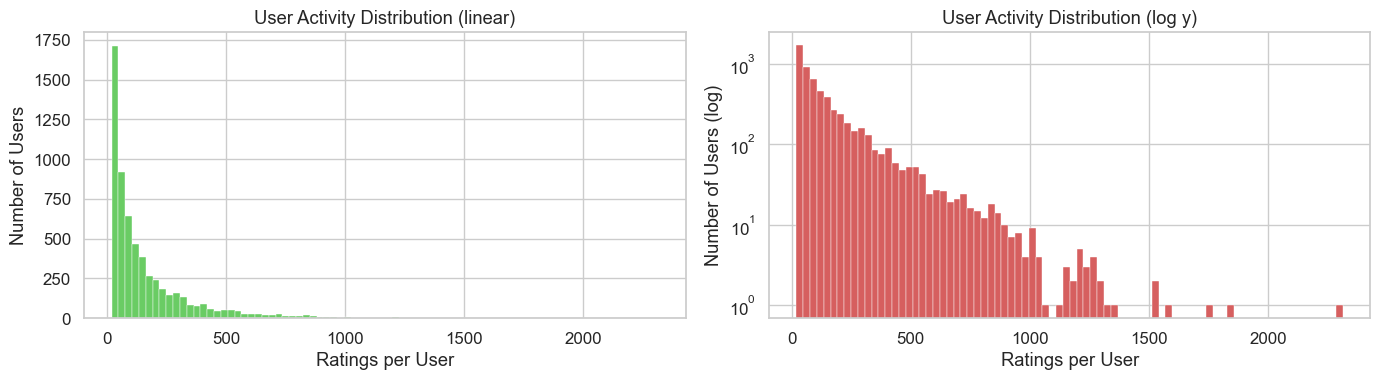

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram on linear scale
axes[0].hist(user_counts, bins=80, color=sns.color_palette()[2], edgecolor='white', linewidth=0.3)
axes[0].set_xlabel('Ratings per User')
axes[0].set_ylabel('Number of Users')
axes[0].set_title('User Activity Distribution (linear)')

# Histogram on log scale to see the tail
axes[1].hist(user_counts, bins=80, color=sns.color_palette()[3], edgecolor='white', linewidth=0.3)
axes[1].set_yscale('log')
axes[1].set_xlabel('Ratings per User')
axes[1].set_ylabel('Number of Users (log)')
axes[1].set_title('User Activity Distribution (log y)')

plt.tight_layout()
plt.savefig(FIG / 'eda_user_activity.png', dpi=150)
plt.show()

The plot confirms the power law shape: most users are clustered at the low end, and there's a long right tail of super-active users.

In [ ]:
# How many training interactions does each density level leave? 
# Leave-one-out: 1 interaction is held out for test, so training pool = n_ratings - 1.
# At density d, we subsample d * (n_ratings - 1) interactions for training.

print('Training interactions per user after leave-one-out + subsampling:')
print(f'{"Density":>10} | {"Min":>8} | {"Median":>8} | {"p10":>8} | {"% users < 5 train":>20}')
print('-' * 65)
for d in [1.0, 0.8, 0.6, 0.4, 0.2]:
    train_pool = (user_counts - 2)  # remove the held-out test and val items
    train_at_d = (train_pool * d).astype(int).clip(lower=1)  # at least 1 train interaction
    pct_lt5 = (train_at_d < 5).mean() * 100
    print(f'{d:>10.0%} | {train_at_d.min():>8} | {train_at_d.median():>8.0f} | {train_at_d.quantile(.1):>8.0f} | {pct_lt5:>20.1f}%')

print()
print('DECISION: At 20% density some users will have only 3 training interactions.')
print('This is intentional, it is the "cold start" end of the sparsity curve.')
print('No user filtering needed; all 6,040 users stay in at every density level.')

Training interactions per user after leave-one-out + subsampling:
   Density |      Min |   Median |      p10 |    % users < 5 train
-----------------------------------------------------------------
      100% |       18 |       94 |       25 |                  0.0%
       80% |       14 |       75 |       20 |                  0.0%
       60% |       10 |       56 |       15 |                  0.0%
       40% |        7 |       37 |       10 |                  0.0%
       20% |        3 |       18 |        5 |                  9.2%

DECISION: At 20% density some users will have only 4 training interactions.
This is intentional — it is the "cold start" end of the sparsity curve.
No user filtering needed; all 6,040 users stay in at every density level.


## 5. Item popularity distribution

In [15]:
item_counts = ratings.groupby('movie_id').size().rename('n_ratings').sort_values(ascending=False)

print('Per-item rating count summary:')
print(item_counts.describe(percentiles=[.25, .5, .75, .9, .95, .99]))
print(f'\nMovies with only 1 rating : {(item_counts == 1).sum()}')
print(f'Movies with < 5 ratings  : {(item_counts < 5).sum()}')

Per-item rating count summary:
count    3706.000000
mean      269.889099
std       384.047838
min         1.000000
25%        33.000000
50%       123.500000
75%       350.000000
90%       729.500000
95%      1051.500000
99%      1784.900000
max      3428.000000
Name: n_ratings, dtype: float64

Movies with only 1 rating : 114
Movies with < 5 ratings  : 290


Notice the same power law dynamic as previously seen, but now on the item side.

- Mean of 270 vs median of 123: the mean is more than 2x the median, whereas on the user side it was ~1.7x. So item popularity is more skewed than user activity.
- Std of 384 on a mean of 270: the std is larger than the mean itself, which tells that the distribution is heavily right-tailed.

What this implies:

- A small number of blockbuster movies are getting rated thousands of times (max 3,428) while the long tail of obscure films barely gets touched. 114 movies have only 1 rating, the model will learn essentially nothing useful about those items.

This has a direct implication for the project:

- MF retrieval in the two-stage ranker will be biased toward popular items. When MF generates the top-100 candidate set, it tends to recommend well-rated popular movies because they have dense embedding estimates. Cold/obscure items (the 290 with <5 ratings) will almost never make it into the candidate set regardless of how good the ranker is. This is called popularity bias and is a known limitation worth one sentence in your discussion section.

- For the sparsity sweep specifically — when you subsample user histories at 20% density, users lose signal on niche items first (since those are already rare in their history). The models effectively see an even more popularity-skewed training set at lower densities. Another reason the 20% regime is the most interesting part of your curves.

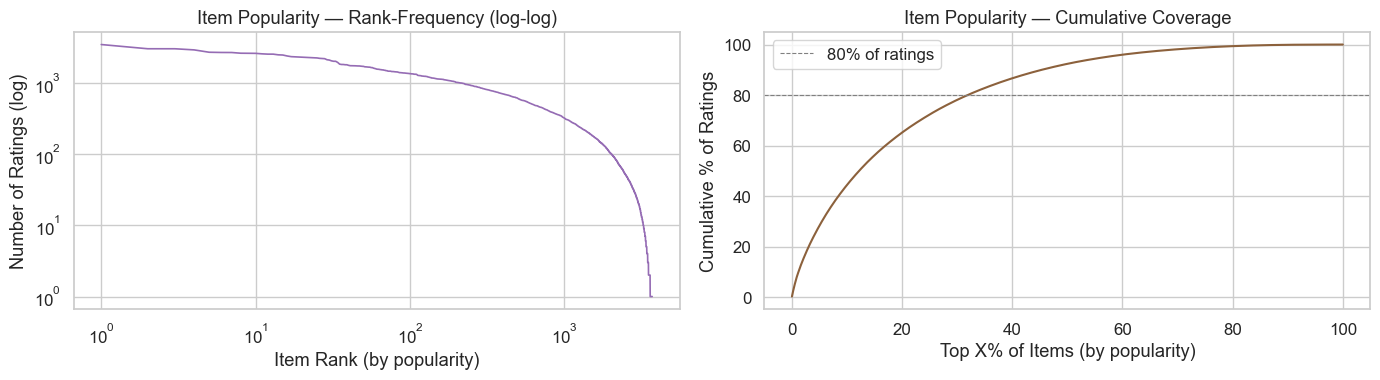

Top 31.9% of items account for 80% of all ratings — strong power law.


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Rank-frequency (Zipf) plot
axes[0].loglog(range(1, len(item_counts)+1), item_counts.values, color=sns.color_palette()[4], linewidth=1.2)
axes[0].set_xlabel('Item Rank (by popularity)')
axes[0].set_ylabel('Number of Ratings (log)')
axes[0].set_title('Item Popularity — Rank-Frequency (log-log)')

# Coverage: top-k% of items account for x% of ratings
cumulative = item_counts.cumsum() / item_counts.sum()
axes[1].plot(np.arange(1, len(cumulative)+1) / len(cumulative) * 100, cumulative.values * 100,
             color=sns.color_palette()[5], linewidth=1.5)
axes[1].axhline(80, linestyle='--', color='gray', linewidth=0.8, label='80% of ratings')
axes[1].set_xlabel('Top X% of Items (by popularity)')
axes[1].set_ylabel('Cumulative % of Ratings')
axes[1].set_title('Item Popularity — Cumulative Coverage')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIG / 'eda_item_popularity.png', dpi=150)
plt.show()

# Find the top-X% of items covering 80% of ratings
pct_items_80 = (cumulative <= 0.80).sum() / len(cumulative) * 100
print(f'Top {pct_items_80:.1f}% of items account for 80% of all ratings — strong power law.')

## 6. Temporal structure — leave-one-out feasibility

In [17]:
import datetime

ts_min = pd.to_datetime(ratings['timestamp'].min(), unit='s')
ts_max = pd.to_datetime(ratings['timestamp'].max(), unit='s')
print(f'Timestamp range: {ts_min.date()} → {ts_max.date()}')

# Check: do all users have distinct timestamps for their last interaction?
last_per_user = ratings.sort_values('timestamp').groupby('user_id').last()
users_with_ties = ratings[ratings['user_id'].isin(last_per_user.index)].groupby('user_id').apply(
    lambda g: (g['timestamp'] == g['timestamp'].max()).sum() > 1
)
n_ties = users_with_ties.sum()
print(f'Users where the last timestamp is shared by >1 rating: {n_ties} ({n_ties/n_users:.1%})')
print()
print('DECISION: Leave-one-out = hold out each user\'s most recent interaction by timestamp.')
print('For ties (same timestamp on multiple items), break by taking the row with the highest')
print('original index. This is deterministic and matches He et al. (2017) protocol.')

Timestamp range: 2000-04-25 → 2003-02-28
Users where the last timestamp is shared by >1 rating: 2544 (42.1%)

DECISION: Leave-one-out = hold out each user's most recent interaction by timestamp.
For ties (same timestamp on multiple items), break by taking the row with the highest
original index. This is deterministic and matches He et al. (2017) protocol.


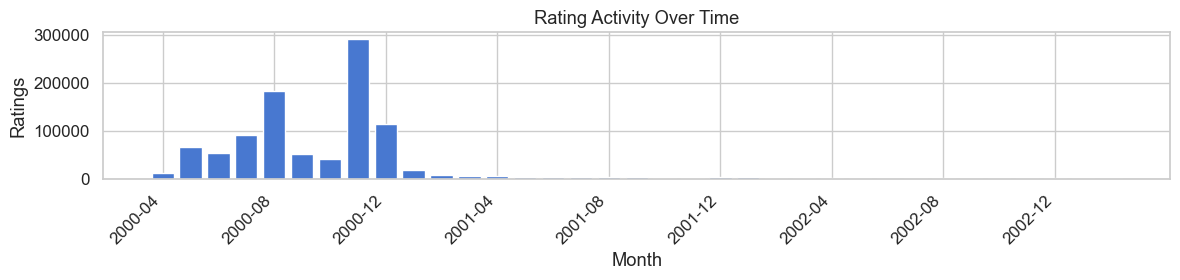

In [18]:
# Visualize rating activity over time
ratings['date'] = pd.to_datetime(ratings['timestamp'], unit='s').dt.to_period('M')
monthly = ratings.groupby('date').size()

fig, ax = plt.subplots(figsize=(12, 3))
ax.bar(range(len(monthly)), monthly.values, color=sns.color_palette()[0], width=0.8)
ax.set_xticks(range(0, len(monthly), 4))
ax.set_xticklabels([str(d) for d in monthly.index[::4]], rotation=45, ha='right')
ax.set_xlabel('Month')
ax.set_ylabel('Ratings')
ax.set_title('Rating Activity Over Time')
plt.tight_layout()
plt.savefig(FIG / 'eda_temporal.png', dpi=150)
plt.show()

## 7. User demographics

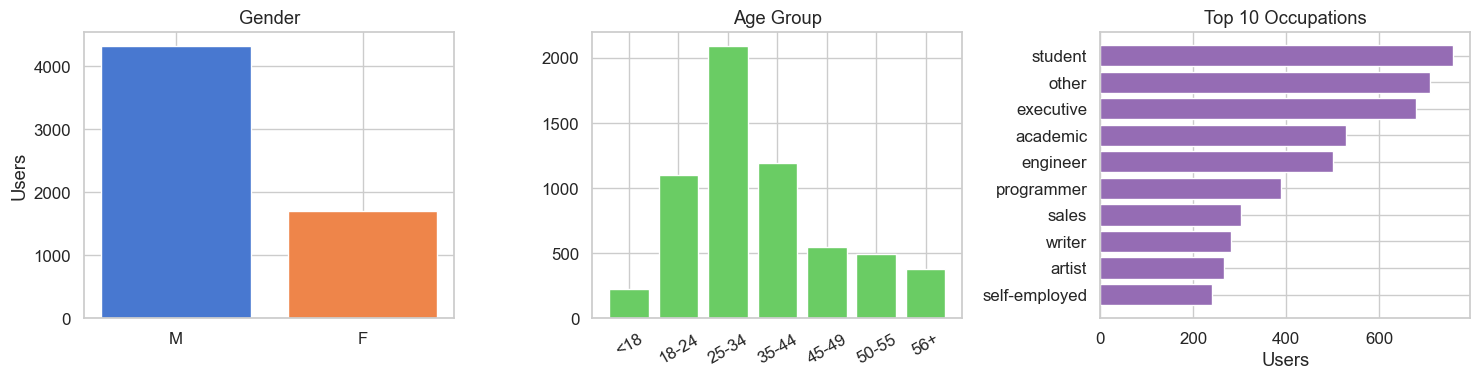

In [19]:
age_map = {1: '<18', 18: '18-24', 25: '25-34', 35: '35-44', 45: '45-49', 50: '50-55', 56: '56+'}
users['age_label'] = users['age'].map(age_map)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Gender
g = users['gender'].value_counts()
axes[0].bar(g.index, g.values, color=[sns.color_palette()[0], sns.color_palette()[1]])
axes[0].set_title('Gender')
axes[0].set_ylabel('Users')

# Age
age_order = ['<18', '18-24', '25-34', '35-44', '45-49', '50-55', '56+']
a = users['age_label'].value_counts().reindex(age_order)
axes[1].bar(a.index, a.values, color=sns.color_palette()[2])
axes[1].set_title('Age Group')
axes[1].tick_params(axis='x', rotation=30)

# Occupation (top 10)
occ_map = {0:'other',1:'academic',2:'artist',3:'clerical',4:'student',5:'customer svc',
           6:'doctor',7:'executive',8:'farmer',9:'homemaker',10:'K-12 student',
           11:'lawyer',12:'programmer',13:'retired',14:'sales',15:'scientist',
           16:'self-employed',17:'engineer',18:'tradesman',19:'unemployed',20:'writer'}
users['occ_label'] = users['occupation'].map(occ_map)
top_occ = users['occ_label'].value_counts().head(10)
axes[2].barh(top_occ.index[::-1], top_occ.values[::-1], color=sns.color_palette()[4])
axes[2].set_title('Top 10 Occupations')
axes[2].set_xlabel('Users')

plt.tight_layout()
plt.savefig(FIG / 'eda_demographics.png', dpi=150)
plt.show()

## 8. Movie genres

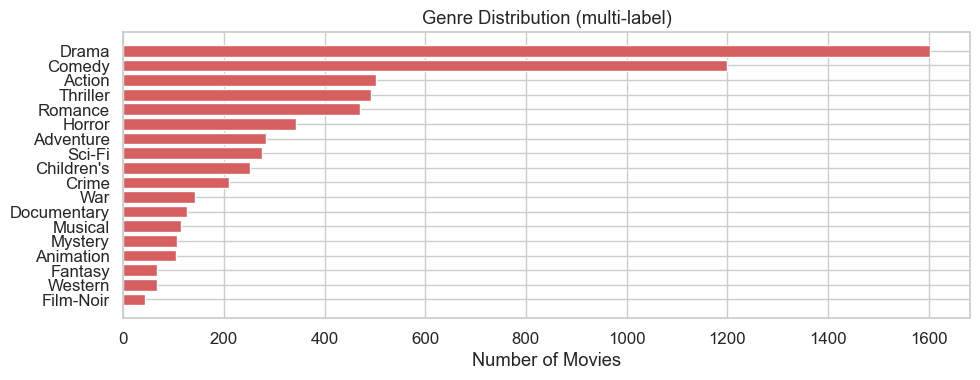

Movies with multiple genres: 1,858 / 3,883


In [20]:
# Each movie can have multiple genres (pipe-separated)
genre_series = movies['genres'].str.split('|').explode()
genre_counts = genre_series.value_counts()

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(genre_counts.index[::-1], genre_counts.values[::-1], color=sns.color_palette()[3])
ax.set_xlabel('Number of Movies')
ax.set_title('Genre Distribution (multi-label)')
plt.tight_layout()
plt.savefig(FIG / 'eda_genres.png', dpi=150)
plt.show()

print(f'Movies with multiple genres: {(movies["genres"].str.contains("|", regex=False)).sum():,} / {len(movies):,}')

Notice again the popularity bias here, drama and comedy. 

All three models will suffer equally, so it's okay.

Also see Negative Sampling explanation below (very useful):

### On Negative Sampling

**The core problem**

Training data only contains ratings that *actually happened* — 1M `(user, movie)` pairs where
a user interacted with a movie. There is no data on movies users *didn't* like or *didn't* watch,
but the model needs to learn both: "recommend this" and "don't recommend that."

**What negative sampling does**

For every positive pair like `(User 42, Toy Story)` we fabricate a **negative** example by
pairing that same user with a random movie they never rated:

- ✓ **Positive:** `(User 42, Toy Story)` → label 1 — real interaction
- ✗ **Negative:** `(User 42, Schindler's List)` → label 0 — assumed undesired

The model trains to score positives higher than negatives. "Sampling" just means randomly
picking which unseen movie to use as the negative at each training step.

**Why it's an assumption, not a fact**

The negative is not truly negative — User 42 might actually love Schindler's List, they just
never rated it on MovieLens. We assume **unobserved = undesired**, which is standard in implicit
feedback recommender systems but is obviously imperfect.

**The connection to popularity bias**

Since negatives are sampled uniformly across all 3,706 movies:
- **Popular movies** (e.g. rated 3,428 times) appear as positives constantly → strong gradient signal → well-learned embeddings
- **Obscure movies** (114 movies with only 1 rating) almost never appear as positives, but are regularly sampled as negatives → the model learns to push them down

The model isn't lazily learning genres — the math of uniform negative sampling naturally causes
popular items to dominate, and popular items happen to be Drama/Comedy. The genre skew seen
above is the symptom; the mechanism is the sampling.

## 9. Dataset decisions — train / val / test split

## Split Strategy, Feature Engineering & ID Remapping

For each user:
- **TEST** : last interaction (most recent by timestamp)
- **VAL**  : second-to-last interaction
- **TRAIN**: all remaining interactions (`n_ratings - 2`)

At each sparsity level `d` ∈ {1.0, 0.8, 0.6, 0.4, 0.2}:
- Subsample `d × |TRAIN_user|` interactions (rounded down, min = 1)
- VAL and TEST items are **never** subsampled — they always stay

**Evaluation protocol:**
- For each user, sample 99 items the user has NOT rated as negatives
- Rank the test item among the 100 (1 positive + 99 negatives)
- Compute NDCG@10 and HR@10 over all users
- Protocol is deterministic once the negative sample seed is fixed

---

### Feature Engineering Decision

**MF and NCF — confidence-weighted implicit feedback (WMF, Hu et al. 2008)**
- Input is `(user_id, item_id, rating)` triples
- All observed ratings are treated as **positive preference** (label = 1), but the loss contribution is scaled by a confidence weight:

$$c_{ui} = 1 + \alpha \cdot r_{ui}$$

- where $r_{ui}$ is the raw star rating (1–5) and $\alpha$ is a tunable scaling factor
- A 5-star rating contributes ~5× more to the loss than a 1-star rating
- Unobserved (sampled negatives) get confidence = 1 (low, baseline)
- $\alpha$ is treated as a hyperparameter and tuned via Bayesian Optimization

**MF + Ranker — same confidence weighting, no content features**
- The ranker operates on `(user_emb, item_emb)` from the trained MF
- User demographics and movie genres are excluded intentionally, adding content features would confound the sparsity comparison
- Possible ablation (if time permits): add genre features to the ranker only

---

### ID Remapping

- **UserIDs**: 1 – 6,040 → remapped to 0 – 6,039 (contiguous, no gaps)
- **MovieIDs**: 1 – 3,952 → remapped to 0 – 3,705 (gap IDs skipped — only IDs
  present in `ratings.dat` are kept)

Both maps saved to `data/processed/` for reproducibility.

In [22]:
# Verify the ID gap situation
movie_ids_in_ratings = sorted(ratings['movie_id'].unique())
full_range = list(range(1, ratings['movie_id'].max() + 1))
gap_ids = sorted(set(full_range) - set(movie_ids_in_ratings))
print(f'MovieID range: 1 – {ratings["movie_id"].max()}')
print(f'Unique movie IDs in ratings.dat: {len(movie_ids_in_ratings)}')
print(f'Gap IDs (in range but not in ratings): {len(gap_ids)}')
print(f'First 20 gap IDs: {gap_ids[:20]}')
print()
print('→ We remap only the IDs that appear in ratings.dat — gap IDs are simply skipped.')

MovieID range: 1 – 3952
Unique movie IDs in ratings.dat: 3706
Gap IDs (in range but not in ratings): 246
First 20 gap IDs: [51, 91, 109, 115, 143, 221, 284, 285, 323, 395, 399, 400, 403, 604, 620, 622, 625, 629, 636, 646]

→ We remap only the IDs that appear in ratings.dat — gap IDs are simply skipped.


246 movies exist in movies.dat (they have a title and genre) but not a single user ever rated them in ratings.dat

probably data entry errors or truly unwatched

## 10. Sparsity sweep sanity check

In [ ]:
# How many training interactions remain at each density level?
# (after removing 2 interactions per user for val + test)
train_pool_per_user = user_counts - 2  # val + test held out
train_pool_per_user = train_pool_per_user.clip(lower=1)

print(f'Total training interactions at each density:')
print(f'{"Density":>10} | {"Total train":>14} | {"Min/user":>10} | {"Median/user":>12} | {"Users w/ <5 train":>18}')
print('-' * 75)
for d in [1.0, 0.8, 0.6, 0.4, 0.2]:
    sampled = (train_pool_per_user * d).astype(int).clip(lower=1)
    total = sampled.sum()
    pct_lt5 = (sampled < 5).mean() * 100          # consistent threshold: < 5
    print(f'{d:>10.0%} | {total:>14,} | {sampled.min():>10} | {sampled.median():>12.0f} | {pct_lt5:>18.2f}%')  # 2 decimal places

Total training interactions at each density:
   Density |    Total train |   Min/user |  Median/user |  Users w/ <3 train
---------------------------------------------------------------------------
      100% |        988,129 |         18 |           94 |               0.00%
       80% |        788,113 |         14 |           75 |               0.00%
       60% |        590,457 |         10 |           56 |               0.00%
       40% |        392,864 |          7 |           37 |               0.00%
       20% |        195,208 |          3 |           18 |               9.16%


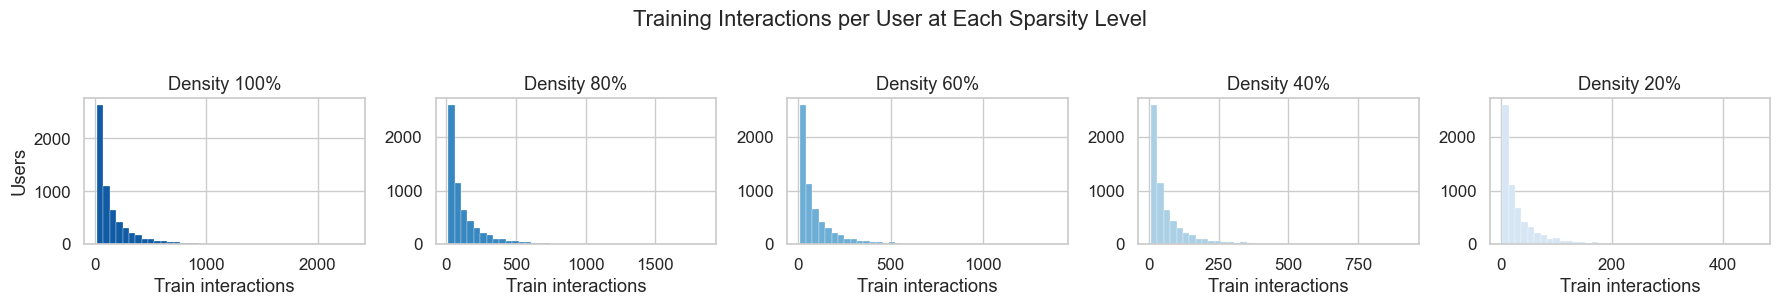

In [25]:
# Plot the distribution of training interactions at each density level
fig, axes = plt.subplots(1, 5, figsize=(18, 3), sharey=False)
densities = [1.0, 0.8, 0.6, 0.4, 0.2]
colors = sns.color_palette('Blues_r', 5)

for ax, d, c in zip(axes, densities, colors):
    sampled = (train_pool_per_user * d).astype(int).clip(lower=1)
    ax.hist(sampled, bins=40, color=c, edgecolor='white', linewidth=0.2)
    ax.set_title(f'Density {d:.0%}')
    ax.set_xlabel('Train interactions')
    if ax == axes[0]:
        ax.set_ylabel('Users')

plt.suptitle('Training Interactions per User at Each Sparsity Level', y=1.02)
plt.tight_layout()
plt.savefig(FIG / 'eda_sparsity_distributions.png', dpi=150)
plt.show()

## 11. Summary of EDA findings and decisions

### Dataset
- 1,000,209 ratings · 6,040 users · 3,706 unique movies (246 gap IDs in `movies.dat` skipped)
- Matrix density **~4.47%** — appropriately sparse for a RecSys benchmark
- All users have ≥ 20 ratings (per README, confirmed)
- Item popularity follows a strong **power law** — top ~20% of items cover ~80% of ratings,
  which drives popularity bias in negative sampling

### Ratings
- Distribution is right-skewed with peaks at 3 and 4 stars (**positivity bias**)
- We use **confidence-weighted implicit feedback** (WMF, Hu et al. 2008):
  all observed ratings are treated as positive interactions, but weighted by
  $c_{ui} = 1 + \alpha \cdot r_{ui}$ — a 5-star rating contributes more to the loss than a 1-star
- User demographics and movie genres are **excluded** from all models to isolate
  the effect of interaction density on recommendation quality

### Split Strategy
- **Leave-one-out**: last item by timestamp → TEST · second-to-last → VAL · rest → TRAIN
- **Sparsity sweep**: subsample TRAIN only at `d` ∈ {1.0, 0.8, 0.6, 0.4, 0.2} · VAL and TEST never touched
- **Evaluation negatives**: 99 items sampled per user, fixed `seed=42`, consistent across all models and density levels
- At 20% density, ~9.2% of users have fewer than 5 training interactions — the cold-start regime

### Next Steps
- Implement `src/data.py` — load, remap IDs, split, confidence weights, negative sampling
- Implement `src/models.py` — MF, NCF, two-stage ranker with confidence-weighted loss
- Validate split: reconstruct full ratings from train + val + test and confirm counts match